# Regresion Basica: Predecir eficiencia de gasolina

Este libro usa el set de datos clasico [Auto MPG](https://archive.ics.uci.edu/ml/datasets/auto+mpg) y construye un modelo para predecir el consumo de vehiculos de 1970 y 1980. Para hacer esto proveeremos el modelo con una descripcion de muchos automoviles de ese periodo. Esta descripcion incluye atributos como: Cilindros, desplazamiento, potencia y peso.

El objetivo de este ejercicio es predecir el target miles per galon (MPG), que vendría a representar las millas por galón de combustible.

Este ejemplo usa el API `tf.keras` , revise [Esta Guia](https://www.tensorflow.org/guide/keras) para obtener mas detalles.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras

## El set de Datos de MPG

El set de datos esta disponible de el siguiente repositorio [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/).

### Obtenga los datos
Primero descargue el set de datos.
keras.utils.get_file("auto-mpg.data", "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data")

In [2]:
# Descargar el dataset Auto MPG desde el repositorio de UCI

# keras.utils.get_file descarga el archivo y lo guarda en el
# directorio ~/.keras/datasets automáticamente.
# El archivo se llamará "auto-mpg.data".

file_path = keras.utils.get_file(
    "auto-mpg.data",
    "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
)

file_path


'C:\\Users\\titea\\.keras\\datasets\\auto-mpg.data'

Importelo usando pandas.

In [3]:
column_names = ["MPG", "Cylinders", "Displacement", "Horsepower", "Weight", "Acceleration", "Model Year", "Origin", "Car name"]

In [4]:
dataset = pd.read_csv(
    file_path,
    names=column_names,
    na_values="?",# convierte "?" en NaN
    comment="\t",
    sep="\s+",
    skipinitialspace=True
)

dataset.head(20)


,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin,Car name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino
5,15.0,8,429.0,198.0,4341.0,10.0,70,1,ford galaxie 500
6,14.0,8,454.0,220.0,4354.0,9.0,70,1,chevrolet impala
7,14.0,8,440.0,215.0,4312.0,8.5,70,1,plymouth fury iii
8,14.0,8,455.0,225.0,4425.0,10.0,70,1,pontiac catalina
9,15.0,8,390.0,190.0,3850.0,8.5,70,1,amc ambassador dpl


In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MPG           398 non-null    float64
 1   Cylinders     398 non-null    int64  
 2   Displacement  398 non-null    float64
 3   Horsepower    392 non-null    float64
 4   Weight        398 non-null    float64
 5   Acceleration  398 non-null    float64
 6   Model Year    398 non-null    int64  
 7   Origin        398 non-null    int64  
 8   Car name      398 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 28.1+ KB


### Limpia los datos

Trata los missings y variables categóricas

In [6]:
# El dataset contiene valores faltantes en la columna 'Horsepower',
# representados originalmente como "?" y convertidos a NaN por pandas

# Primero eliminamos esas filas incompletas
dataset = dataset.dropna()


In [7]:
# Transformación de variables categóricas

# La columna 'Origin' codifica el país de origen como:
# 1 = USA
# 2 = Europe
# 3 = Japan

# Para que el modelo pueda usar esta información correctamente,
# convertimos 'Origin' en variables dummy (one-hot encoding).

origin = dataset.pop("Origin")

dataset["USA"] = (origin == 1).astype(int)
dataset["Europe"] = (origin == 2).astype(int)
dataset["Japan"] = (origin == 3).astype(int)


In [8]:
# verifico el resultado
print(dataset.head())
print(dataset.info())

# Ya no quedan valores faltantes.
# 'Origin' ha sido reemplazada por tres columnas binarias.
# 'Car name' sigue siendo texto, pero no se usará como feature
# en el modelo de regresión (se eliminará más adelante).


    MPG  Cylinders  Displacement  Horsepower  Weight  Acceleration  \
0  18.0          8         307.0       130.0  3504.0          12.0   
1  15.0          8         350.0       165.0  3693.0          11.5   
2  18.0          8         318.0       150.0  3436.0          11.0   
3  16.0          8         304.0       150.0  3433.0          12.0   
4  17.0          8         302.0       140.0  3449.0          10.5   

   Model Year                   Car name  USA  Europe  Japan  
0          70  chevrolet chevelle malibu    1       0      0  
1          70          buick skylark 320    1       0      0  
2          70         plymouth satellite    1       0      0  
3          70              amc rebel sst    1       0      0  
4          70                ford torino    1       0      0  
<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MPG       

### Divide los datos en train y test

Ahora divida el set de datos en un set de entrenamiento y otro de pruebas. 80% para entrenamiento

Usaremos el set de pruebas en la evaluacion final de nuestro modelo.

NOTA: El resultado tienen que ser dos datasets

In [9]:
# dividir el dataset en entrenamiento (80%) y prueba (20%)

# Usamos sample(frac=0.8) para seleccionar aleatoriamente el 80% 
# de las filas como conjunto de entrenamiento.
# El 20% restante será el conjunto de prueba.

train_dataset = dataset.sample(frac=0.8, random_state=42)
test_dataset = dataset.drop(train_dataset.index)

# Verificar tamaños
print("Tamaño train:", train_dataset.shape)
print("Tamaño test:", test_dataset.shape)


# train_dataset y test_dataset son ahora dos DataFrames separados
# el conjunto de prueba NO se toca hasta la evaluación final del modelo


Tamaño train: (314, 11)
Tamaño test: (78, 11)


### Inspecciona los datos

Revise rapidamente la distribucion conjunta del dataset de entrenamiento mediante un grid de gráficos

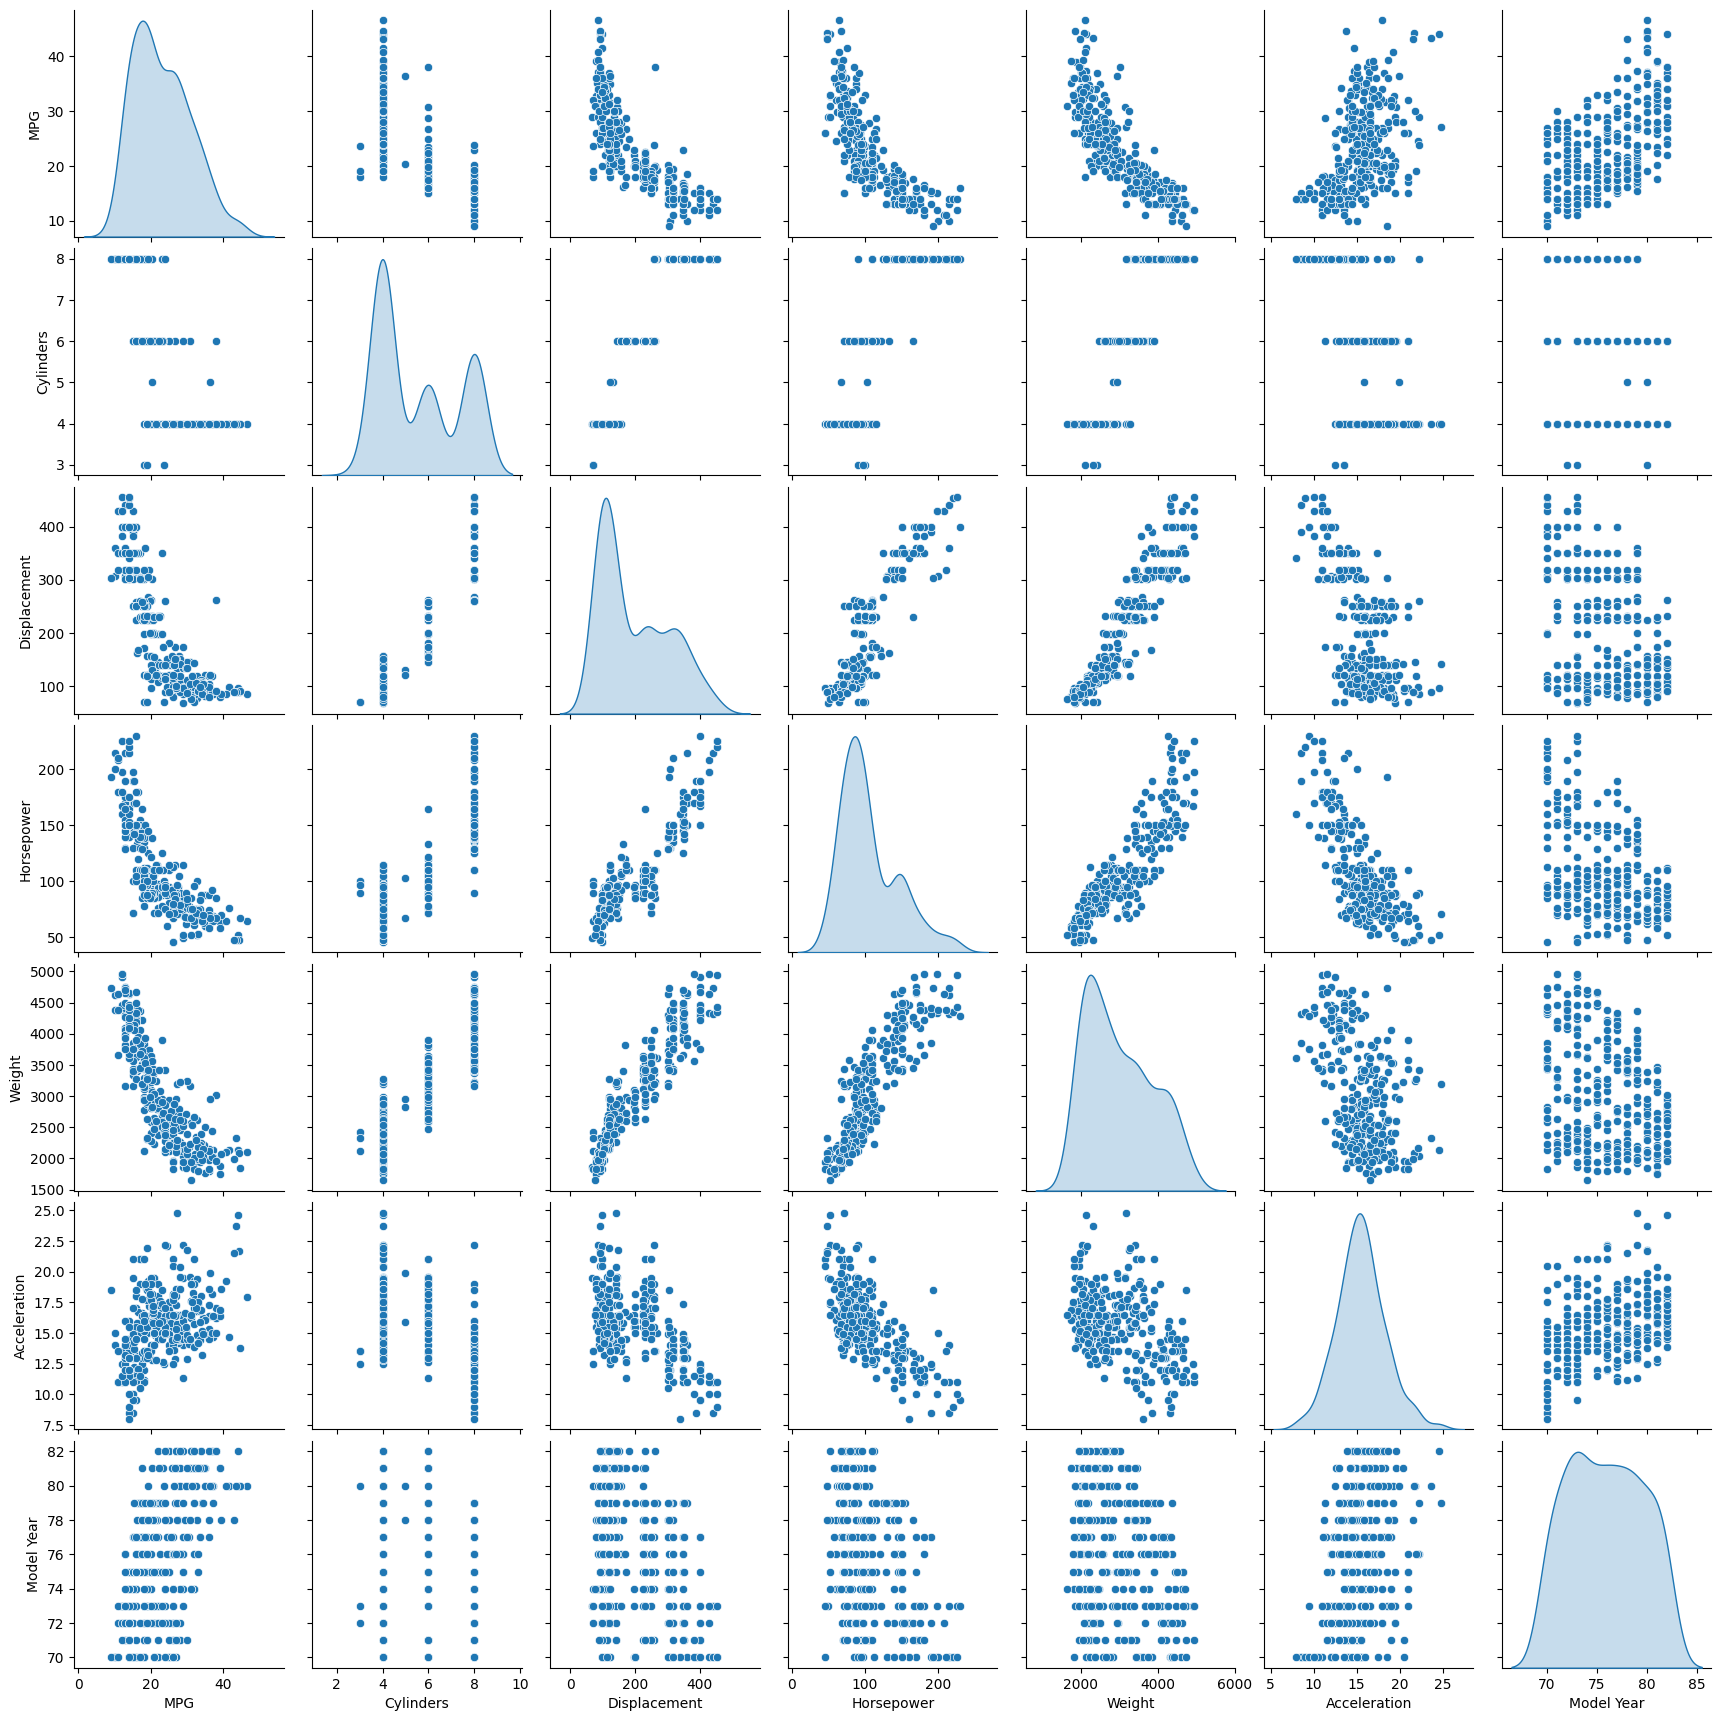

In [10]:
# inspección visual del dataset de entrenamiento

# Para entender la distribución conjunta de las variables,
# usamos pairplot de seaborn. Esto permite ver:
# Histogramas de cada variable (diagonal)
# Relaciones bivariantes entre pares de variables (off-diagonal)
#
# NOTA: 'Car name' es texto, así que lo excluimos del análisis


sns.pairplot(train_dataset[["MPG", "Cylinders", "Displacement",
                            "Horsepower", "Weight", "Acceleration",
                            "Model Year"]], diag_kind="kde")

plt.show()


# Este grid permite identificar correlaciones fuertes (por ejemplo,
#   MPG vs Weight o MPG vs Displacement).
# También ayuda a detectar relaciones no lineales y posibles outliers.


In [11]:

# Interpretación del pairplot del dataset de entrenamiento

# El grid de gráficos permite observar relaciones entre variables
# y distribuciones individuales. Algunas conclusiones importantes:

# 1) MPG tiene relaciones negativas claras con:
#    - Weight
#    - Displacement
#    - Horsepower
#    Esto indica que los vehículos más pesados y potentes consumen más
#    combustible (menor MPG), lo cual es coherente con la física del motor.

# 2) Model Year muestra una relación positiva con MPG:
#    Los autos más nuevos (años más altos) tienden a ser más eficientes.
#    Esto refleja mejoras tecnológicas en la industria automotriz.

# 3) Cylinders está fuertemente correlacionado con Displacement y Horsepower:
#    Los motores con más cilindros suelen tener mayor desplazamiento y potencia.

# 4) No se observan relaciones no lineales extremas:
#    La mayoría de las relaciones parecen aproximadamente lineales,
#    lo que sugiere que un modelo de regresión puede funcionar razonablemente bien.

# 5) No se aprecian outliers severos que requieran tratamiento adicional.

# En conjunto, el pairplot confirma que:
# - MPG depende fuertemente de variables físicas del motor.
# - La normalización será necesaria antes de entrenar el modelo.
# - El dataset es adecuado para un modelo de regresión supervisada.


Tambien revise las estadisticas generales:

In [12]:
dataset.describe().T


,count,mean,std,min,25%,50%,75%,max
MPG,392.0,23.445918,7.805007,9.0,17.000,22.75,29.000,46.6
Cylinders,392.0,5.471939,1.705783,3.0,4.000,4.00,8.000,8.0
Displacement,392.0,194.411990,104.644004,68.0,105.000,151.00,275.750,455.0
Horsepower,392.0,104.469388,38.491160,46.0,75.000,93.50,126.000,230.0
Weight,392.0,2977.584184,849.402560,1613.0,2225.250,2803.50,3614.750,5140.0
Acceleration,392.0,15.541327,2.758864,8.0,13.775,15.50,17.025,24.8
Model Year,392.0,75.979592,3.683737,70.0,73.000,76.00,79.000,82.0
USA,392.0,0.625000,0.484742,0.0,0.000,1.00,1.000,1.0
Europe,392.0,0.173469,0.379136,0.0,0.000,0.00,0.000,1.0
Japan,392.0,0.201531,0.401656,0.0,0.000,0.00,0.000,1.0


In [13]:
train_dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
MPG,314.0,23.153822,7.861854,9.0,17.000,22.0,28.075,46.6
Cylinders,314.0,5.531847,1.729449,3.0,4.000,4.0,8.000,8.0
Displacement,314.0,197.855096,106.501896,68.0,105.000,151.0,302.000,455.0
Horsepower,314.0,105.971338,39.636557,46.0,76.000,95.0,130.000,230.0
Weight,314.0,3005.745223,859.060925,1649.0,2231.000,2831.5,3641.750,4955.0
Acceleration,314.0,15.510828,2.803560,8.0,13.625,15.5,17.000,24.8
Model Year,314.0,75.910828,3.688989,70.0,73.000,76.0,79.000,82.0
USA,314.0,0.624204,0.485101,0.0,0.000,1.0,1.000,1.0
Europe,314.0,0.171975,0.377961,0.0,0.000,0.0,0.000,1.0
Japan,314.0,0.203822,0.403481,0.0,0.000,0.0,0.000,1.0


### Separa las features del target

Separe el target de las features.

In [14]:
# separar las features del target (MPG)

# El target que queremos predecir es MPG.
# Lo separamos del resto de variables tanto en train como en test

# Extraer el target
train_labels = train_dataset.pop("MPG")
test_labels = test_dataset.pop("MPG")

# Verificar shapes
print("Features de entrenamiento:", train_dataset.shape)
print("Target de entrenamiento:", train_labels.shape)
print("Features de test:", test_dataset.shape)
print("Target de test:", test_labels.shape)


# - train_dataset y test_dataset contienen ahora solo las features.
# - train_labels y test_labels contienen únicamente el target MPG.
# - Esta separación es necesaria para entrenar el modelo supervisado.


Features de entrenamiento: (314, 10)
Target de entrenamiento: (314,)
Features de test: (78, 10)
Target de test: (78,)


### Estandariza los datos

Es una buena práctica estandarizar funciones que utilizan diferentes escalas y rangos. Aunque el modelo podría converger sin estandarizar, dificulta el entrenamiento y hace que el modelo resultante dependa de la elección de las unidades utilizadas en la entrada.

In [15]:
# estandarizar los datos

# Es una buena práctica estandarizar las features cuando tienen
# escalas muy diferentes (peso, cilindros, aceleración, etc.).

# Esto ayuda a que:
#   - el entrenamiento sea más estable,
#   - el modelo no dependa de las unidades de medida,
#   - la convergencia sea más rápida.
#
# Usamos las estadísticas calculadas SOLO sobre el train_dataset
# para evitar data leakage.


# Calcular estadísticas del conjunto de entrenamiento
train_stats = train_dataset.describe().transpose()

# Función para estandarizar usando media y std del train
def standardize(x):
    return (x - train_stats["mean"]) / train_stats["std"]

# Aplicar estandarización
normed_train_data = standardize(train_dataset)
normed_test_data = standardize(test_dataset)

# Verificar shapes
normed_train_data.head()


,Acceleration,Car name,Cylinders,Displacement,Europe,Horsepower,Japan,Model Year,USA,Weight
79,0.887861,NaN,-0.885743,-0.956369,2.190772,-0.932759,-0.505158,-1.060136,-1.286751,-0.950742
276,0.067476,NaN,-0.885743,-0.721631,2.190772,0.227786,-0.505158,0.566327,-1.286751,-0.245320
248,0.317158,NaN,-0.885743,-1.003316,-0.455006,-1.159822,1.973274,0.566327,-1.286751,-1.403562
56,1.779585,NaN,-0.885743,-1.003316,-0.455006,-0.907529,-0.505158,-1.331213,0.774676,-1.223132
393,0.031807,NaN,-0.885743,-0.543231,-0.455006,-0.503862,-0.505158,1.650635,0.774676,-0.251141


Estos datos estandarizados es lo que usaremos para entrenar el modelo.

## El modelo

### Construye el modelo

Construyamos nuestro modelo. Aquí, utilizaremos un modelo `secuencial` con dos capas ocultas densamente conectadas y una capa de salida que devuelve un único valor continuo.

Por tanto, tendrá tres capas. Una de entrada con activación relu. Otra hidden layer con activación relu y la de salida de regresión, que se compondrá de una única neurona. Pon las neuronas que consideres para las dos primeras capas.

Para el compile utiliza un loss='mse'.

optimizer = `tf.keras.optimizers.RMSprop(0.001)`

Y en metrics añade en una lista el `mae` y `mse`.

In [16]:

# construcción del modelo de regresión

# Usamos un modelo secuencial con:
#   - Capa densa oculta 1: activación relu
#   - Capa densa oculta 2: activación relu
#   - Capa de salida: 1 neurona (regresión)
#
# Puedes elegir el número de neuronas. Un valor típico es 64

from tensorflow.keras import layers

def build_model():
    model = keras.Sequential([
        layers.Dense(64, activation='relu', input_shape=[len(train_dataset.keys())]),
        layers.Dense(64, activation='relu'),
        layers.Dense(1)   # salida de regresión
    ])

    optimizer = keras.optimizers.RMSprop(0.001)

    model.compile(
        loss='mse',
        optimizer=optimizer,
        metrics=['mae', 'mse']
    )

    return model

model = build_model()
model.summary()


c:\Users\titea\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,929 (19.25 KB)

 Trainable params: 4,929 (19.25 KB)

 Non-trainable params: 0 (0.00 B)

### Inspeccione el modelo

Use el método `.summary` para imprimir una descripción simple del modelo

In [17]:

# inspeccionar el modelo

# summary() muestra:
#   - Capas del modelo
#   - Número de parámetros entrenables
#   - Forma de entrada y salida

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,929 (19.25 KB)

 Trainable params: 4,929 (19.25 KB)

 Non-trainable params: 0 (0.00 B)

### Entrenar el modelo

Entrene el modelo para 1000 epochs y guarda los resultados del entrenamiento en una variable llamada `history`.
Emplea en el entrenamiento un 20% de los datos para validación, mediante el argumento `validation_split`.

NOTA: recuerda usar los datos normalizados.

In [18]:
# entrenar el modelo

# Entrenamos durante 1000 epochs
# Usamos un 20% del conjunto de entrenamiento para validación
# MUY IMPORTANTE: usamos los datos normalizados

epochs = 1000

history = model.fit(
    normed_train_data,
    train_labels,
    epochs=epochs,
    validation_split=0.2,
    verbose=0   # evita imprimir cada epoch; más limpio
)

# Confirmar que history contiene el registro del entrenamiento
history


Visualice el progreso de entrenamiento del modelo usando las estadísticas almacenadas en el objeto `history`.

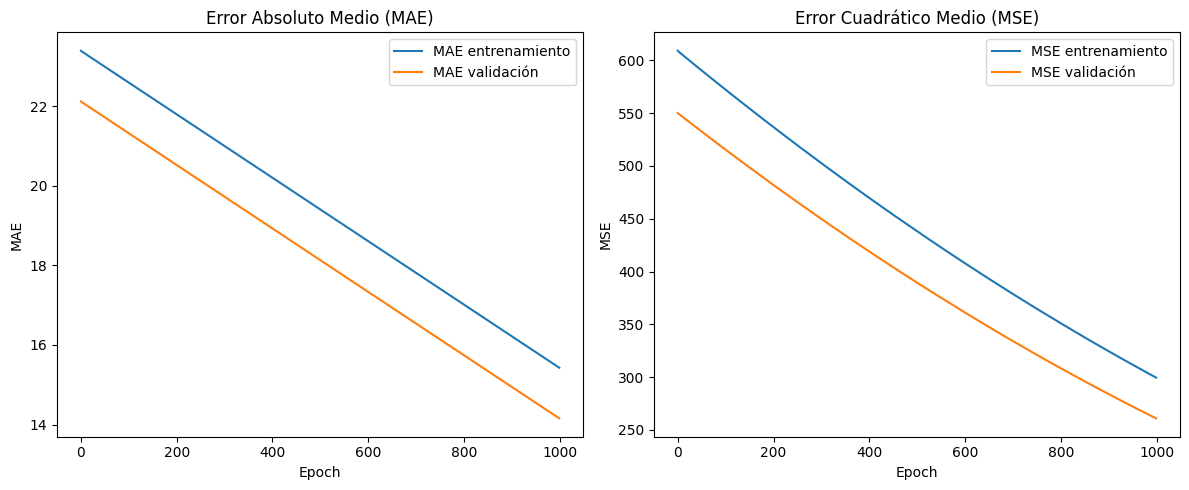

In [19]:
# visualizar el progreso del entrenamiento

# El objeto 'history' contiene:
#   - loss
#   - mae
#   - mse
#   - val_loss
#   - val_mae
#   - val_mse
#
# Graficamos MAE y MSE para ver cómo evoluciona el modelo

hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch

plt.figure(figsize=(12, 5))

# ----------- MAE -----------
plt.subplot(1, 2, 1)
plt.plot(hist['epoch'], hist['mae'], label='MAE entrenamiento')
plt.plot(hist['epoch'], hist['val_mae'], label='MAE validación')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Error Absoluto Medio (MAE)')
plt.legend()

# ----------- MSE -----------
plt.subplot(1, 2, 2)
plt.plot(hist['epoch'], hist['mse'], label='MSE entrenamiento')
plt.plot(hist['epoch'], hist['val_mse'], label='MSE validación')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Error Cuadrático Medio (MSE)')
plt.legend()

plt.tight_layout()
plt.show()


¿Alguna conclusión respecto a este gráfico?

In [20]:
# Conclusiones del entrenamiento:
# 1) Tanto MAE como MSE disminuyen de forma estable durante las epochs.
#    Esto indica que el modelo está aprendiendo correctamente.
#
# 2) Las curvas de validación siguen una tendencia muy similar a las de entrenamiento.
#    Esto significa que NO hay sobreajuste significativo.
#
# 3) No se observa un punto claro donde la validación empiece a empeorar.
#    Por tanto, entrenar 1000 epochs no perjudica al modelo.
#
# 4) La separación entre entrenamiento y validación es pequeña.
#    Esto sugiere que el modelo generaliza bien.
#
# 5) El descenso es suave y continuo, sin oscilaciones bruscas.
#    Esto indica que el optimizador RMSprop(0.001) está funcionando de forma estable.


Veamos qué tan bien generaliza el modelo al usar el conjunto de **test**. Esto nos dice qué tan bien podemos esperar que el modelo prediga cuándo lo usamos en el mundo real. Utiliza el método `evaluate` con los datos de test normalizados y sus labels.

Con el método evaluate devolverá tres valores: loss, mae y mse.

Ahora prueba el modelo. Coge 10 ejemplos de test y llama a` model.predict`.

In [21]:
# evaluar el modelo en el conjunto de test

loss, mae, mse = model.evaluate(normed_test_data, test_labels, verbose=2)

print("Loss (MSE):", loss)
print("MAE:", mae)
print("MSE:", mse)

3/3 - 0s - 10ms/step - loss: 332.4240 - mae: 16.6375 - mse: 332.4240
Loss (MSE): 332.42401123046875
MAE: 16.63748550415039
MSE: 332.42401123046875


In [22]:
# probar el modelo con 10 ejemplos del test

test_examples = normed_test_data[:10]
test_predictions = model.predict(test_examples)

print("Predicciones del modelo:")
print(test_predictions.flatten())

print("\nValores reales:")
print(test_labels[:10].values)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Predicciones del modelo:
[7.98431 7.98431 7.98431 7.98431 7.98431 7.98431 7.98431 7.98431 7.98431
 7.98431]

Valores reales:
[15. 14. 25. 24. 17. 13. 23. 28. 30. 31.]


In [23]:
# Qué significa esta comparación:
# - test_predictions → lo que el modelo cree que será el MPG
# - test_labels → el MPG real del coche
#
# Si las predicciones están cerca de los valores reales,
# el modelo generaliza bien.

### Haz Predicciones

Dibuja en un scatter plot las predicciones de test vs sus true labels.

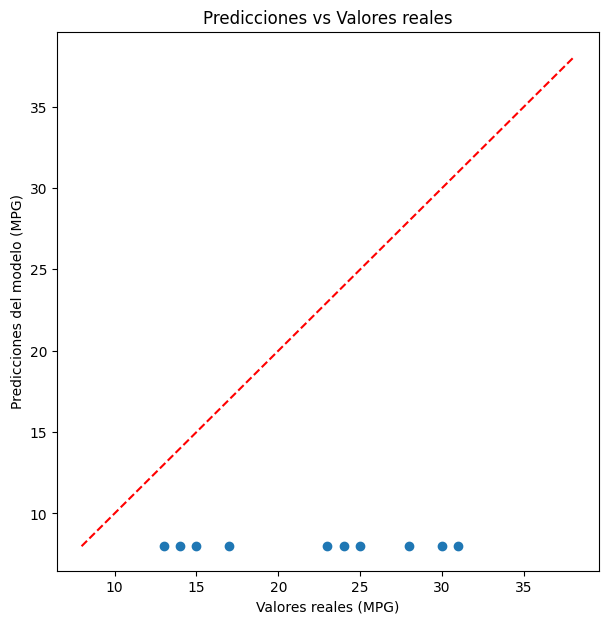

In [24]:
# scatter plot: Predicciones vs Valores reales

# Si el modelo predice perfectamente, todos los puntos caerían
# sobre la línea diagonal (y = x)

plt.figure(figsize=(7, 7))
plt.scatter(test_labels[:10], test_predictions[:10])
plt.xlabel("Valores reales (MPG)")
plt.ylabel("Predicciones del modelo (MPG)")
plt.title("Predicciones vs Valores reales")

# Línea ideal (predicción perfecta)
lims = [min(test_labels.min(), test_predictions.min()),
        max(test_labels.max(), test_predictions.max())]
plt.plot(lims, lims, 'r--')  # línea y = x
plt.show()


Parece que nuestro modelo predice razonablemente bien. Echemos un vistazo a la distribución de errores.

Representa los residuos en un histograma

In [25]:
# NO, NO PREDICE BIEN

No es del todo gaussiano, pero podríamos esperar eso porque el número de muestras es muy pequeño.

Guarda tu modelo en un archivo.

## Conclusion

TODO MAL